# Conduct a analysis of the performance


In [2]:
import pandas
import duckdb
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import seaborn as sns

# 1.Read & load the results from the databases crash test

In [3]:
file_path = './benchmarker/database_benchmark_results3.csv'
results_df = pandas.read_csv(file_path)
results_df.columns

Index(['query', 'original_query', 'database_type', 'execution_time_ms',
       'cpu_usage_percent', 'memory_usage_mb', 'memory_usage_percent',
       'disk_read_mb', 'disk_write_mb', 'network_in_mb', 'network_out_mb',
       'result_rows', 'result_size_mb', 'failed', 'memory_limit', 'cpu_limit'],
      dtype='object')

In [7]:
duckdb.sql("SELECT * EXCLUDE(query, original_query) FROM './benchmarker/database_benchmark_results3.csv';").df()


,database_type,execution_time_ms,cpu_usage_percent,memory_usage_mb,memory_usage_percent,disk_read_mb,disk_write_mb,network_in_mb,network_out_mb,result_rows,result_size_mb,failed,memory_limit,cpu_limit
0,MySQLHandler,22.236586,2.448235,2047.628906,99.981880,0.0,0.0,0.010686,2.287437,1000,3.920194,False,2G,2
1,MySQLHandler,320.349455,0.722174,2046.410156,99.922371,0.0,0.0,0.001489,0.001817,1,0.000134,False,2G,2
2,MySQLHandler,1119.115829,0.762423,2047.960938,99.998093,0.0,0.0,0.002541,0.092213,3097,0.234960,False,2G,2
3,MySQLHandler,1613.100767,0.619339,2047.171875,99.959564,0.0,0.0,0.018212,4.039487,151168,11.281813,False,2G,2
4,MySQLHandler,435.337305,0.733741,2047.179688,99.959946,0.0,0.0,0.001628,0.001935,1,0.000156,False,2G,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122,ClickHouseHandler,17.496824,5.689278,1662.261719,2.536410,0.0,0.0,0.003627,0.082846,3097,0.234960,False,64G,18
1123,ClickHouseHandler,669.582844,9.617817,1726.105469,2.633828,0.0,0.0,0.006526,3.509484,154682,11.508680,False,64G,18
1124,ClickHouseHandler,6.343842,5.198251,1675.878906,2.557188,0.0,0.0,0.002777,0.004660,1,0.000156,False,64G,18
1125,ClickHouseHandler,3437.883139,7.110488,1692.550781,2.582628,0.0,0.0,0.026143,251.749416,115044,419.288275,False,64G,18


In [6]:
# check if results return failed queries
failed = results_df[results_df['failed'] == True]
failed

#print(failed['original_query'].values)

,query,original_query,database_type,execution_time_ms,cpu_usage_percent,memory_usage_mb,memory_usage_percent,disk_read_mb,disk_write_mb,network_in_mb,network_out_mb,result_rows,result_size_mb,failed,memory_limit,cpu_limit


In [9]:
# Display initial data info
results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1127 entries, 0 to 1126
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   query                 1127 non-null   object 
 1   original_query        1127 non-null   object 
 2   database_type         1127 non-null   object 
 3   execution_time_ms     1127 non-null   float64
 4   cpu_usage_percent     1127 non-null   float64
 5   memory_usage_mb       1127 non-null   float64
 6   memory_usage_percent  1127 non-null   float64
 7   disk_read_mb          1127 non-null   float64
 8   disk_write_mb         1127 non-null   float64
 9   network_in_mb         1127 non-null   float64
 10  network_out_mb        1127 non-null   float64
 11  result_rows           1127 non-null   int64  
 12  result_size_mb        1127 non-null   float64
 13  failed                1127 non-null   bool   
 14  memory_limit          1127 non-null   object 
 15  cpu_limit            

In [10]:
# change results_df memory_limit to integer
results_df = duckdb.sql("""
SELECT 
    * EXCLUDE(memory_limit),
    replace(memory_limit, 'G',''):: integer as memory_limit
FROM './benchmarker/database_benchmark_results3.csv'; 
""").df()

results_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1127 entries, 0 to 1126
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   query                 1127 non-null   object 
 1   original_query        1127 non-null   object 
 2   database_type         1127 non-null   object 
 3   execution_time_ms     1127 non-null   float64
 4   cpu_usage_percent     1127 non-null   float64
 5   memory_usage_mb       1127 non-null   float64
 6   memory_usage_percent  1127 non-null   float64
 7   disk_read_mb          1127 non-null   float64
 8   disk_write_mb         1127 non-null   float64
 9   network_in_mb         1127 non-null   float64
 10  network_out_mb        1127 non-null   float64
 11  result_rows           1127 non-null   int64  
 12  result_size_mb        1127 non-null   float64
 13  failed                1127 non-null   bool   
 14  cpu_limit             1127 non-null   int64  
 15  memory_limit         

In [11]:
results_df.describe()

,execution_time_ms,cpu_usage_percent,memory_usage_mb,memory_usage_percent,disk_read_mb,disk_write_mb,network_in_mb,network_out_mb,result_rows,result_size_mb,cpu_limit,memory_limit
count,1127.000000,1127.000000,1127.000000,1127.000000,1127.0,1127.0,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000
mean,2943.930745,2.152287,1727.222590,23.470591,0.0,0.0,0.124941,28.328250,57325.683230,64.027185,8.857143,21.826087
std,11714.057522,2.713487,1111.941561,30.287497,0.0,0.0,0.433446,78.882311,65869.323847,146.703703,5.223937,21.758523
min,2.125978,0.000799,100.183594,0.152928,0.0,0.0,0.000000,0.000000,1.000000,0.000134,2.000000,2.000000
25%,20.758271,0.006496,100.707031,2.597356,0.0,0.0,0.000000,0.000000,1.000000,0.000156,4.000000,4.000000
50%,153.299809,0.911000,2020.351562,9.876406,0.0,0.0,0.002903,0.082720,3097.000000,3.920194,8.000000,16.000000
75%,1202.790856,2.468528,2109.033203,39.307523,0.0,0.0,0.018562,3.478911,127197.000000,11.281813,14.000000,32.000000
max,62790.190458,17.793159,3300.445312,99.999428,0.0,0.0,2.102222,264.643103,154682.000000,433.563977,18.000000,64.000000


# 2. Analyse the results with SQL in duckdb

In [71]:
duckdb.sql("SUMMARIZE results_df").df()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,query,VARCHAR,/* COUNT ALL */ SELECT COUNT(*) FROM data,/* TOP 1000 ROWS */ SELECT * FROM data LIMIT 1000,12,None,None,None,None,None,1127,0.0
1,original_query,VARCHAR,-- COUNT ALL\nSELECT COUNT(*) FROM data,-- TOP 1000 ROWS\nSELECT * FROM data LIMIT 1000,7,None,None,None,None,None,1127,0.0
2,database_type,VARCHAR,ClickHouseHandler,PostgresHandler,4,None,None,None,None,None,1127,0.0
3,execution_time_ms,DOUBLE,2.125978469848633,62790.19045829773,1045,2943.9307452305925,11714.057521529301,20.732952488793266,153.6373586365671,1186.8147002260866,1127,0.0
4,cpu_usage_percent,DOUBLE,0.0007992507024664377,17.793158551810237,857,2.15228743876423,2.713487271068349,0.0074712601945159255,0.9404773560232795,2.475213086873612,1127,0.0
5,memory_usage_mb,DOUBLE,100.18359375,3300.4453125,830,1727.2225903948536,1111.9415609770315,100.76674804687501,2021.1651173963905,2111.4337369791665,1127,0.0
6,memory_usage_percent,DOUBLE,0.15292763710021973,99.99942779541016,901,23.470591419866473,30.287497484743625,2.6381197950196644,9.864783597489199,37.90172343783908,1127,0.0
7,disk_read_mb,DOUBLE,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0,1127,0.0
8,disk_write_mb,DOUBLE,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0,1127,0.0
9,network_in_mb,DOUBLE,0.0,2.102222442626953,327,0.12494107020461888,0.43344602470887555,5.511177910698784e-05,0.0029097461370448338,0.019564831649864115,1127,0.0


In [13]:
results_df.columns 

Index(['query', 'original_query', 'database_type', 'execution_time_ms',
       'cpu_usage_percent', 'memory_usage_mb', 'memory_usage_percent',
       'disk_read_mb', 'disk_write_mb', 'network_in_mb', 'network_out_mb',
       'result_rows', 'result_size_mb', 'failed', 'cpu_limit', 'memory_limit'],
      dtype='object')

In [14]:
print(results_df['memory_limit'].unique())
print(results_df['cpu_limit'].unique())

[ 2  4  8 16 32 64]
[ 2  4  6  8 10 14 18]


## Overall Performance Analysis

In [15]:
# based on summarized infos, we use the results only from the the highest values of ram & cpu

top_df = duckdb.sql("""
SELECT
    *
FROM results_df
WHERE memory_limit = '64' AND cpu_limit = 18;
""").df()

print(top_df['memory_limit'].unique())
print(top_df['cpu_limit'].unique())

[64]
[18]


## Execution time

In [16]:
# Lets attribute a color per database
color_map = {
   'ClickHouseHandler': 'lemonchiffon',  
   'DuckDBHandler': 'gold',
   'PostgresHandler': 'royalblue',
   'MySQLHandler': 'orangered'  
    }


In [70]:
# get average, median, min, max execution time
execution_time = duckdb.sql("""
SELECT 
    database_type,
    ROUND(AVG(execution_time_ms), 2) as avg_execution_time_ms,
    ROUND(MEDIAN(execution_time_ms), 2) as median_execution_time_ms,
    ROUND(MIN(execution_time_ms), 2) as min_execution_time_ms, 
    ROUND(MAX(execution_time_ms), 2) as max_execution_time_ms,
    ROUND(SUM(execution_time_ms),2) as total_execution_time
FROM top_df
GROUP BY database_type
ORDER BY avg_execution_time_ms;
""")

execution_time.df()

,database_type,avg_execution_time_ms,median_execution_time_ms,min_execution_time_ms,max_execution_time_ms,total_execution_time
0,DuckDBHandler,343.50,19.15,2.56,1924.00,2404.52
1,PostgresHandler,525.87,73.24,20.75,1644.80,3681.11
2,ClickHouseHandler,691.89,36.33,6.34,3437.88,4843.24
3,MySQLHandler,9876.19,1027.34,22.90,62273.31,69133.35


### Total & Median execution time by Database

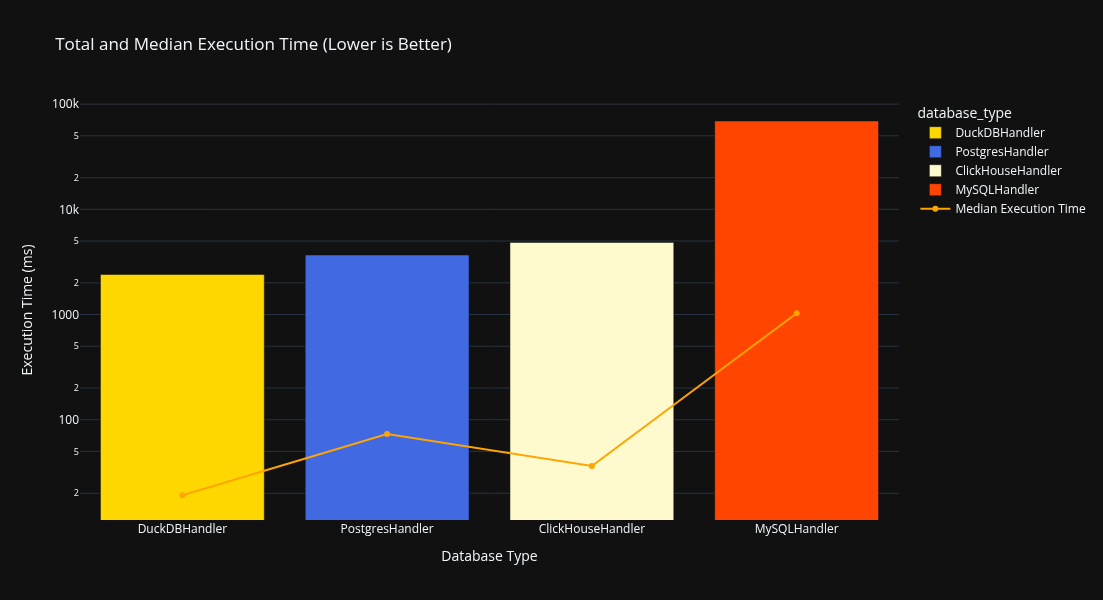

In [18]:
# define the template for all charts
template='plotly_dark'

execution_time_df = execution_time.df()

total_execution_plot = px.bar(
    execution_time_df, 
    x='database_type', 
    y='total_execution_time',
    title='Total Execution Time in ms (lower is better)',
    template=template,
    height=600,
    width=800,
    color='database_type',
    color_discrete_map=color_map
    
)


# Add a line trace to the existing figure
total_execution_plot.add_trace(go.Scatter(
    x=execution_time_df['database_type'],  
    y=execution_time_df['median_execution_time_ms'],
    mode='lines+markers',
    name='Median Execution Time',
    marker={'color': 'orange'},
    

))

# update layout
total_execution_plot.update_layout(
    title='Total and Median Execution Time (Lower is Better)',
    xaxis_title='Database Type',
    yaxis_title='Execution Time (ms)',
    yaxis_type='log'

)
total_execution_plot.show()


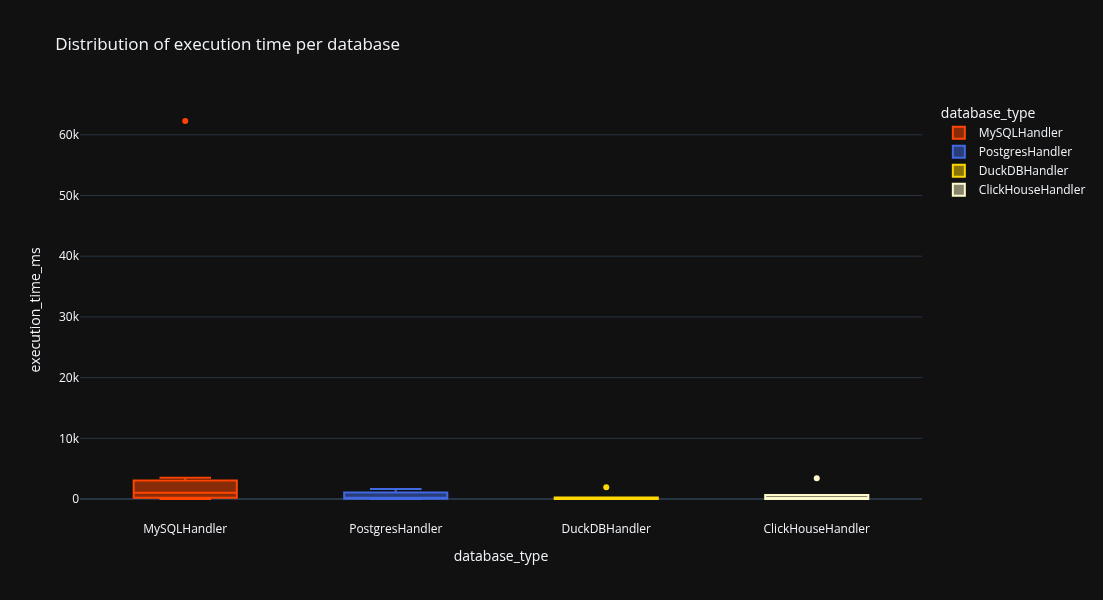

In [19]:
execution_time_box = px.box(
    top_df,
    x='database_type',
    y='execution_time_ms',
    title='Distribution of execution time per database',
    #labels={'database_type': 'Database System', 'cpu_usage_percent': 'Average CPU Utilization (%)'},
    template=template,
    height=600,
    width=800,
    color='database_type',
    color_discrete_map=color_map
)

execution_time_box.show()

## Cpu usage

In [20]:
# cpu usage in percent
cpu_usage = duckdb.sql(
    """SELECT 
    database_type,
    ROUND(AVG(cpu_usage_percent), 4) as avg_cpu_percent,
    ROUND(MEDIAN(cpu_usage_percent), 4) as median_cpu_usage_percent,
    ROUND(MIN(cpu_usage_percent), 4) as min_cpu_usage_percent, 
    ROUND(MAX(cpu_usage_percent), 4) as max_cpu_usage_percent,
    ROUND(SUM(cpu_usage_percent), 2) as total_cpu_usage
    FROM top_df
    GROUP BY database_type
    ORDER BY avg_cpu_percent
    """
    )

cpu_usage

┌───────────────────┬─────────────────┬──────────────────────────┬───────────────────────┬───────────────────────┬─────────────────┐
│   database_type   │ avg_cpu_percent │ median_cpu_usage_percent │ min_cpu_usage_percent │ max_cpu_usage_percent │ total_cpu_usage │
│      varchar      │     double      │          double          │        double         │        double         │     double      │
├───────────────────┼─────────────────┼──────────────────────────┼───────────────────────┼───────────────────────┼─────────────────┤
│ DuckDBHandler     │           0.005 │                    0.005 │                0.0034 │                0.0059 │            0.03 │
│ MySQLHandler      │          1.0718 │                   0.7579 │                0.6055 │                2.3131 │             7.5 │
│ PostgresHandler   │          1.5501 │                   2.0005 │                0.1359 │                2.2004 │           10.85 │
│ ClickHouseHandler │          7.3248 │                   7.1105 │   

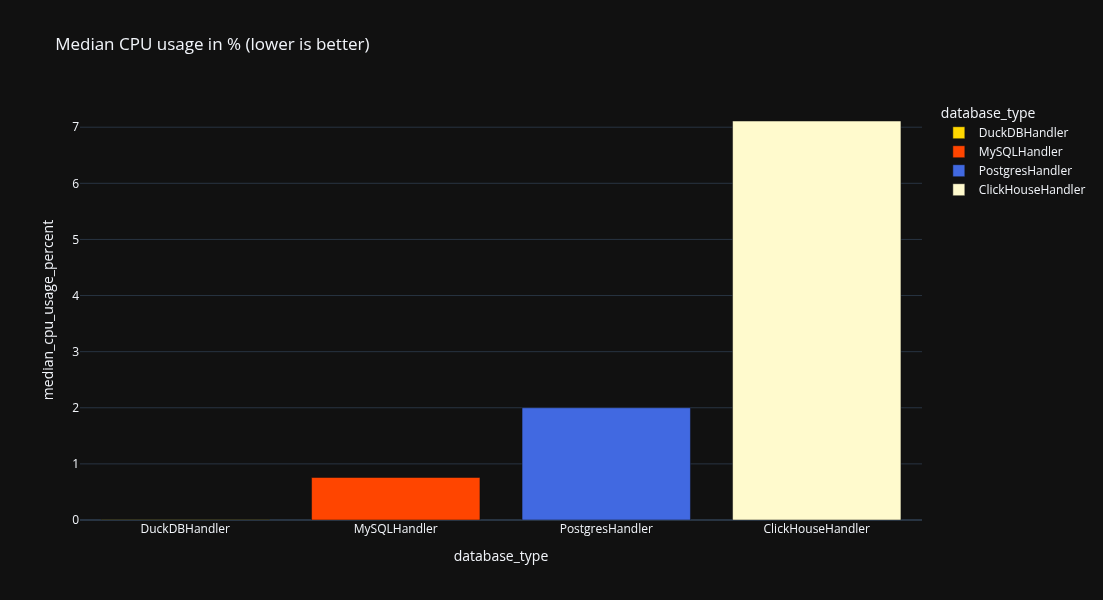

In [21]:
# create a ploty viz 
cpu_usage_plot = px.bar(
    cpu_usage, 
    x='database_type', 
    y='median_cpu_usage_percent',
    title='Median CPU usage in % (lower is better)',
    template=template,
    height=600,
    width=800,
    color='database_type',
    color_discrete_map=color_map
)

cpu_usage_plot.show()

### Memory usage

analyse the min, max, avg, median memory usage in percentage

In [22]:
mem_usage_percent = duckdb.sql(
    """SELECT 
    database_type,
    ROUND(AVG(memory_usage_percent), 2) as avg_memory_usage_percent,
    ROUND(MEDIAN(memory_usage_percent), 2) as median_memory_usage_percent,
    ROUND(MIN(memory_usage_percent), 2) as min_memory_usage_percent, 
    ROUND(MAX(memory_usage_percent), 2) as max_memory_usage_percent
    FROM top_df
    GROUP BY database_type
    ORDER BY median_memory_usage_percent
    """
    )

mem_usage_percent

┌───────────────────┬──────────────────────────┬─────────────────────────────┬──────────────────────────┬──────────────────────────┐
│   database_type   │ avg_memory_usage_percent │ median_memory_usage_percent │ min_memory_usage_percent │ max_memory_usage_percent │
│      varchar      │          double          │           double            │          double          │          double          │
├───────────────────┼──────────────────────────┼─────────────────────────────┼──────────────────────────┼──────────────────────────┤
│ DuckDBHandler     │                     0.15 │                        0.15 │                     0.15 │                     0.15 │
│ ClickHouseHandler │                     2.59 │                        2.56 │                     2.53 │                     2.74 │
│ PostgresHandler   │                     3.19 │                        3.18 │                     3.17 │                     3.23 │
│ MySQLHandler      │                     4.96 │                     

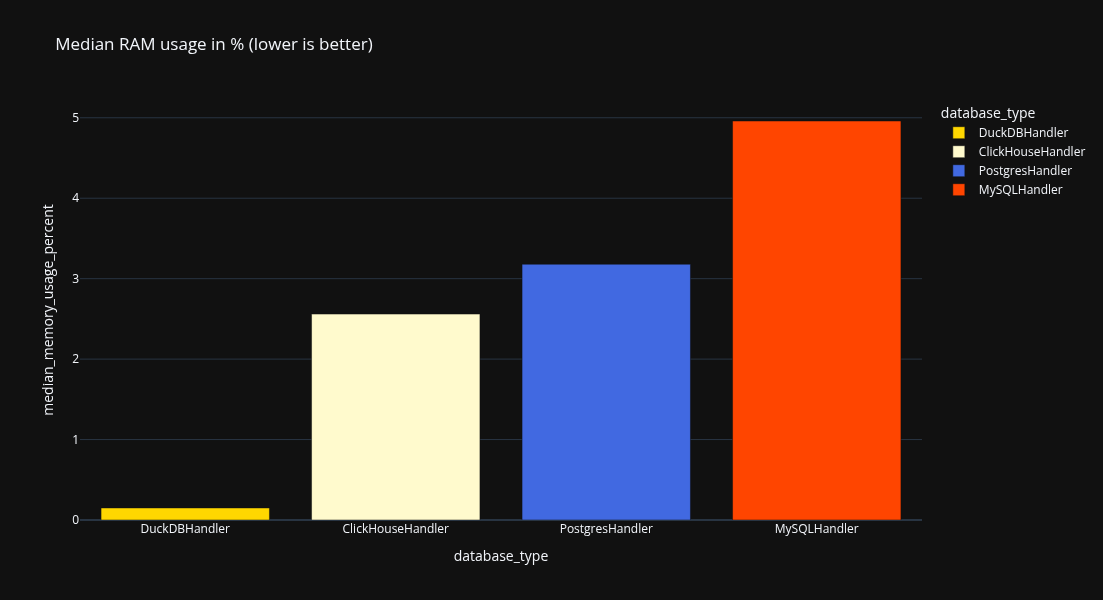

In [23]:
# create a ploty viz 
mem_usage_plot = px.bar(
    mem_usage_percent, 
    x='database_type', 
    y='median_memory_usage_percent',
    title='Median RAM usage in % (lower is better)',
    template=template,
    height=600,
    width=800,
    color='database_type',
    color_discrete_map=color_map
)

mem_usage_plot.show()

In [24]:
mem_usage_mb = duckdb.sql(
    """SELECT 
    database_type,
    ROUND(AVG(memory_usage_mb), 2) as avg_memory_usage_mb,
    ROUND(MEDIAN(memory_usage_mb), 2) as median_memory_usage_mb,
    ROUND(MIN(memory_usage_mb), 2) as min_memory_usage_mb, 
    ROUND(MAX(memory_usage_mb), 2) as max_memory_usage_mb,
    ROUND(SUM(memory_usage_mb), 2) as total_memory_usage_mb
    FROM top_df
    GROUP BY database_type
    ORDER BY total_memory_usage_mb
    """
    ).df()

mem_usage_mb

,database_type,avg_memory_usage_mb,median_memory_usage_mb,min_memory_usage_mb,max_memory_usage_mb,total_memory_usage_mb
0,DuckDBHandler,100.79,100.79,100.79,100.79,705.55
1,ClickHouseHandler,1697.22,1675.88,1659.21,1798.08,11880.57
2,PostgresHandler,2091.46,2084.52,2076.72,2119.56,14640.23
3,MySQLHandler,3247.76,3251.93,3218.66,3288.85,22734.32


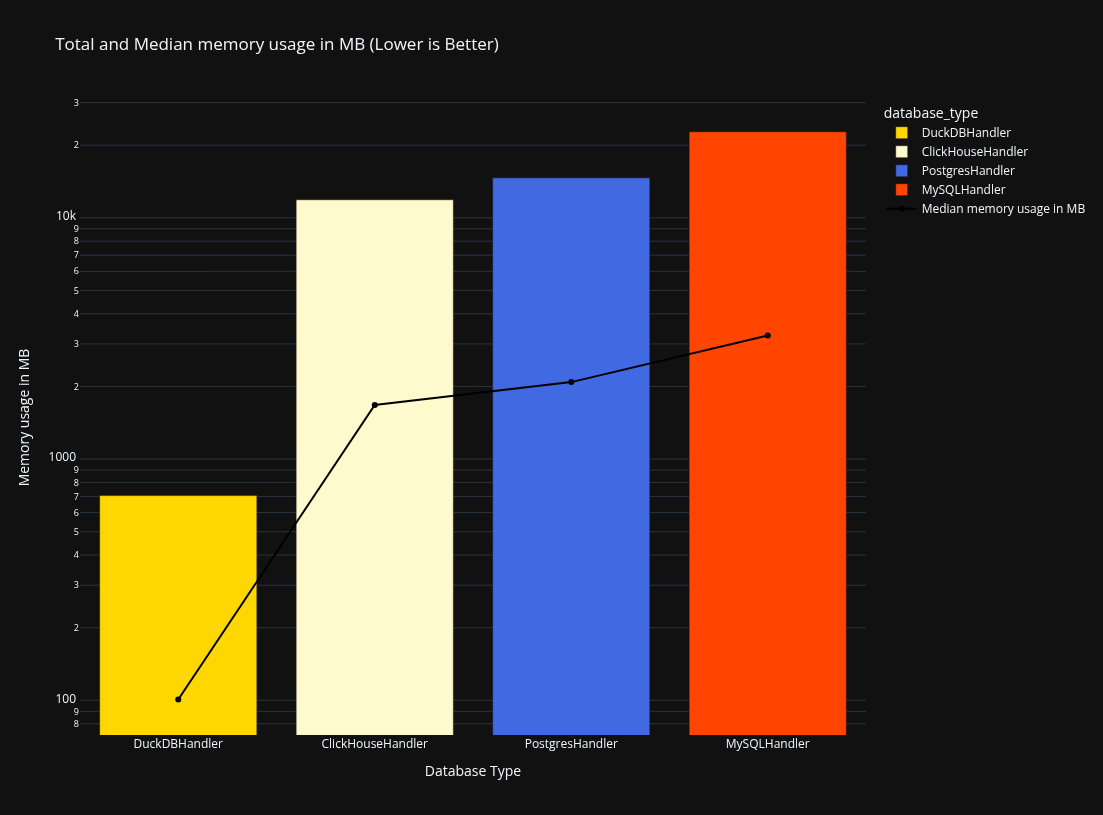

In [25]:
total_memory_mb_plot = px.bar(
    mem_usage_mb, 
    x='database_type', 
    y='total_memory_usage_mb',
    title='Total memory usage in MB (lower is better)',
    template=template,
    height=800,
    width=1200,
    color='database_type',
    color_discrete_map=color_map
)

# Add a line trace to the existing figure
total_memory_mb_plot.add_trace(go.Scatter(
    x=mem_usage_mb['database_type'],  
    y=mem_usage_mb['median_memory_usage_mb'],
    mode='lines+markers',
    name='Median memory usage in MB',  
    marker={'color': 'black'}  
))



# update layout
total_memory_mb_plot.update_layout(
    title='Total and Median memory usage in MB (Lower is Better)',
    xaxis_title='Database Type',
    yaxis_title='Memory usage in MB',
    yaxis_type='log'
)
total_memory_mb_plot.show()

### Scatter plot 
Compare the memory usage (MB) with the execution time (ms)

In [26]:
results_df.columns

Index(['query', 'original_query', 'database_type', 'execution_time_ms',
       'cpu_usage_percent', 'memory_usage_mb', 'memory_usage_percent',
       'disk_read_mb', 'disk_write_mb', 'network_in_mb', 'network_out_mb',
       'result_rows', 'result_size_mb', 'failed', 'cpu_limit', 'memory_limit'],
      dtype='object')

In [69]:
mem_execution_time = duckdb.sql(
    """SELECT 
        database_type,
        ROUND(execution_time_ms, 2) as execution_time_ms,
        ROUND(memory_usage_mb, 2) as memory_usage_mb,
        ROUND(memory_usage_percent,2 ) as memory_usage_percent,
        ROUND(SUM(memory_usage_mb), 2) as total_memory_usage_mb
    FROM top_df
    GROUP BY ALL
    ORDER BY database_type;
    """
    )
mem_execution_time.df()

,database_type,execution_time_ms,memory_usage_mb,memory_usage_percent,total_memory_usage_mb
0,ClickHouseHandler,669.58,1726.11,2.63,1726.11
1,ClickHouseHandler,3437.88,1692.55,2.58,1692.55
2,ClickHouseHandler,668.60,1798.08,2.74,1798.08
3,ClickHouseHandler,7.01,1659.21,2.53,1659.21
4,ClickHouseHandler,17.50,1662.26,2.54,1662.26
5,ClickHouseHandler,6.34,1675.88,2.56,1675.88
6,ClickHouseHandler,36.33,1666.48,2.54,1666.48
7,DuckDBHandler,2.91,100.79,0.15,100.79
8,DuckDBHandler,19.15,100.79,0.15,100.79
9,DuckDBHandler,1924.00,100.79,0.15,100.79


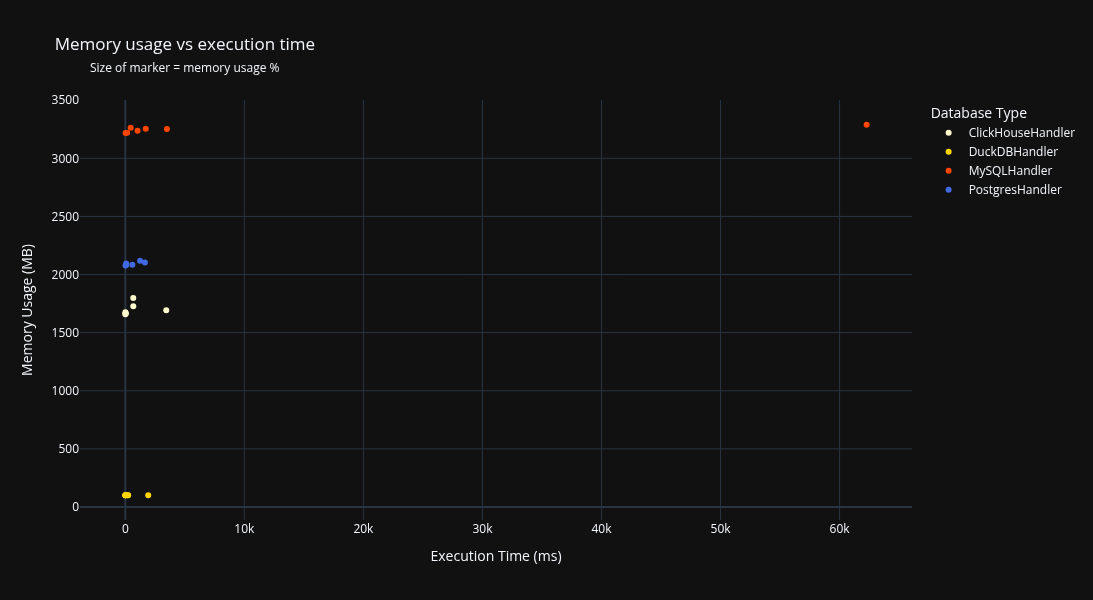

In [37]:
mem_execution = px.scatter(
   mem_execution_time,
   x='execution_time_ms',
   y='memory_usage_mb',
   color='database_type',
   # size='total_memory_usage_mb',
   title='Memory usage vs execution time',
   color_discrete_map=color_map,
   template=template,
   height=600,
   width=800,
   #log_x=True,
   #log_y=True
)

mem_execution.update_layout(
    xaxis_title="Execution Time (ms)",
    yaxis_title="Memory Usage (MB)",
    legend_title="Database Type",

    annotations=[
        dict(xref='paper', yref='paper',
             x=.01, y=1.1,
             showarrow=False,
             text="Size of marker = memory usage %",
             font=dict(size=12),
             align="left")
    ]   
)
mem_execution.show()

In [38]:
top_df.columns
top_df['database_type'].unique()


array(['MySQLHandler', 'PostgresHandler', 'DuckDBHandler',
       'ClickHouseHandler'], dtype=object)

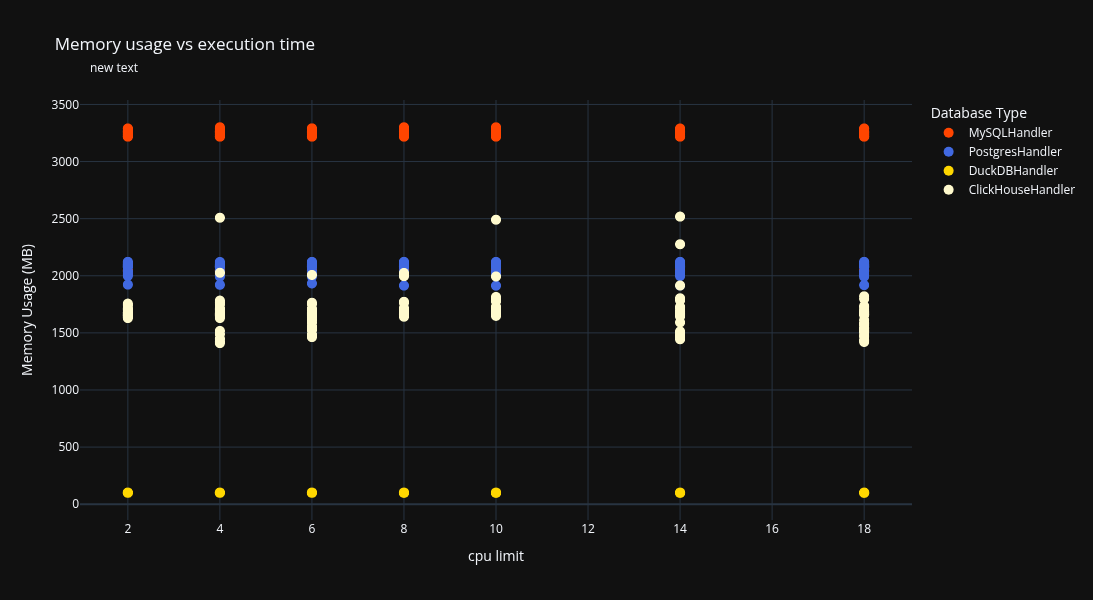

In [39]:
mem_ram_execution = px.scatter(
   results_df,
   x='cpu_limit',
   y='memory_usage_mb',
   color='database_type',
   #size='execution_time_ms',
   title='Memory usage vs execution time',
   color_discrete_map=color_map,
   template=template,
   height=600,
   width=800,
   #log_x=True,
   #log_y=True
)

mem_ram_execution.update_traces(marker_size=10)

mem_ram_execution.update_layout(
    xaxis_title="cpu limit",
    yaxis_title="Memory Usage (MB)",
    legend_title="Database Type",

    annotations=[
        dict(xref='paper', yref='paper',
             x=.01, y=1.1,
             showarrow=False,
             #text="Size of marker = memory usage %",
             font=dict(size=12),
             align="left")
    ]   
)
mem_ram_execution.show()

## Query execution time analysis

In [40]:
results_df[results_df['database_type'] == 'DuckDBHandler'].describe()


,execution_time_ms,cpu_usage_percent,memory_usage_mb,memory_usage_percent,disk_read_mb,disk_write_mb,network_in_mb,network_out_mb,result_rows,result_size_mb,cpu_limit,memory_limit
count,294.000000,294.000000,294.000000,294.000000,294.0,294.0,2.940000e+02,294.0,294.000000,294.000000,294.000000,294.000000
mean,317.926173,0.004571,100.447266,1.609036,0.0,0.0,9.082613e-07,0.0,57308.428571,63.502125,8.857143,21.000000
std,620.015681,0.001192,0.156195,1.662129,0.0,0.0,7.746752e-06,0.0,66008.800361,145.562116,5.230522,21.693333
min,2.125978,0.000799,100.183594,0.152928,0.0,0.0,0.000000e+00,0.0,1.000000,0.000134,2.000000,2.000000
25%,2.959490,0.004099,100.339844,0.306821,0.0,0.0,0.000000e+00,0.0,1.000000,0.000156,4.000000,4.000000
50%,18.916368,0.004794,100.494141,0.918663,0.0,0.0,0.000000e+00,0.0,3097.000000,3.920194,8.000000,12.000000
75%,201.290965,0.005071,100.542969,2.453518,0.0,0.0,0.000000e+00,0.0,127334.000000,11.508657,14.000000,32.000000
max,1924.002171,0.009694,100.792969,4.912949,0.0,0.0,6.675720e-05,0.0,154682.000000,419.287655,18.000000,64.000000


In [68]:
query_time = duckdb.sql(
    """
    SELECT 
        ROUND(MEDIAN(execution_time_ms),1) as median_execution_time_ms,
        ROUND(AVG(execution_time_ms),1) as avg_execution_time_ms,
        CASE
            WHEN original_query LIKE '%JOIN%' THEN 'Join Query'
            WHEN original_query LIKE  '%OVER%' THEN 'Window Function'
            WHEN original_query LIKE '%SELECT * FROM% WHERE%%' THEN 'Filter Query'
            WHEN original_query LIKE '%AVG%' 
                OR original_query LIKE '%SUM%'
                OR original_query LIKE '%COUNT%'
                OR original_query LIKE '%MIN%'
                OR original_query LIKE '%MAX%' 
                OR original_query LIKE '%MEDIAN%'THEN 'Aggregate Query'
            WHEN original_query LIKE '%ORDER BY%' THEN 'Sort Query'
            ELSE 'Select Query'
        END AS query_category,
        original_query as query
    FROM top_df
    GROUP BY ALL
    ORDER BY 1 DESC
    LIMIT 10;
    """
)
query_time.df()

,median_execution_time_ms,avg_execution_time_ms,query_category,query
0,2680.9,2624.6,Select Query,-- FILTER BY LIKE OPERATOR & 2 CONDITIONS\nSEL...
1,954.8,16105.1,Join Query,-- SELF-JOIN ON 'artist' TO FIND DUPLICATE ART...
2,630.7,796.8,Aggregate Query,-- DISTINCT VALUES IN COLUMN 'album'\nSELECT \...
3,42.3,280.4,Aggregate Query,-- DISTINCT VALUES & COUNT OF 'genre'\nSELECT ...
4,39.8,133.5,Aggregate Query,"-- STATS (AVG, SUM, MIN, MAX) FOR COLUMN 'temp..."
5,24.8,50.4,Aggregate Query,-- COUNT ALL\nSELECT COUNT(*) FROM data
6,21.8,24.8,Select Query,-- TOP 1000 ROWS\nSELECT * FROM data LIMIT 1000


In [66]:
ranked_queries = duckdb.sql("""
SELECT
    database_type,
    ROUND(execution_time_ms, 2) as execution_time_ms,
    ROW_NUMBER() OVER (PARTITION BY database_type ORDER BY execution_time_ms DESC) as rank_longest_query,
    
    CASE
        WHEN original_query LIKE '%JOIN%' THEN 'Join Query'
        WHEN original_query LIKE '%OVER%' THEN 'Window Function'
        WHEN original_query LIKE '%WHERE%' THEN 'Filter Clause'
        WHEN original_query LIKE '%AVG%' 
          OR original_query LIKE '%SUM%'
          OR original_query LIKE '%COUNT%'
          OR original_query LIKE '%MIN%'
          OR original_query LIKE '%MAX%' 
          OR original_query LIKE '%MEDIAN%'THEN 'Aggregate Query'
        WHEN original_query LIKE '%GROUP BY%' THEN 'Group By'
        WHEN original_query LIKE '%ORDER BY%' THEN 'Sorted Query'
        ELSE 'Select Query'
    END AS query_category,
    original_query AS query
FROM
    top_df
WHERE database_type != 'MySQLHandler'
--QUALIFY rank_longest_query <= 10
ORDER BY database_type; 
""" )

ranked_queries.df()

,database_type,execution_time_ms,rank_longest_query,query_category,query
0,ClickHouseHandler,3437.88,1,Filter Clause,-- FILTER BY LIKE OPERATOR & 2 CONDITIONS\nSEL...
1,ClickHouseHandler,669.58,2,Aggregate Query,-- DISTINCT VALUES IN COLUMN 'album'\nSELECT \...
2,ClickHouseHandler,668.60,3,Join Query,-- SELF-JOIN ON 'artist' TO FIND DUPLICATE ART...
3,ClickHouseHandler,36.33,4,Select Query,-- TOP 1000 ROWS\nSELECT * FROM data LIMIT 1000
4,ClickHouseHandler,17.50,5,Aggregate Query,-- DISTINCT VALUES & COUNT OF 'genre'\nSELECT ...
5,ClickHouseHandler,7.01,6,Aggregate Query,-- COUNT ALL\nSELECT COUNT(*) FROM data
6,ClickHouseHandler,6.34,7,Aggregate Query,"-- STATS (AVG, SUM, MIN, MAX) FOR COLUMN 'temp..."
7,DuckDBHandler,1924.00,1,Filter Clause,-- FILTER BY LIKE OPERATOR & 2 CONDITIONS\nSEL...
8,DuckDBHandler,237.59,2,Join Query,-- SELF-JOIN ON 'artist' TO FIND DUPLICATE ART...
9,DuckDBHandler,208.52,3,Aggregate Query,-- DISTINCT VALUES IN COLUMN 'album'\nSELECT \...


In [67]:
# Assuming 'top_df' is already available
aggregated_queries = duckdb.sql("""
WITH categorized_queries AS (
    SELECT
        database_type,
        execution_time_ms,
        CASE
            WHEN original_query LIKE '%JOIN%' THEN 'Join Query'
            WHEN original_query LIKE '%OVER%' THEN 'Window Function'
            WHEN original_query LIKE '%WHERE%' THEN 'Filter Clause'
            WHEN original_query LIKE '%GROUP BY%' THEN 'Group By'
            WHEN original_query LIKE '%AVG%' OR original_query LIKE '%SUM%' OR original_query LIKE '%COUNT%' OR original_query LIKE '%MIN%' OR original_query LIKE '%MAX%' OR original_query LIKE '%MEDIAN%' THEN 'Aggregate Query'
            WHEN original_query LIKE '%ORDER BY%' THEN 'Sorted Query'
            ELSE 'Select Query'
        END AS query_category
    FROM
        top_df
)

SELECT
    database_type,
    query_category,
    AVG(execution_time_ms) AS avg_execution_time_ms
FROM
    categorized_queries
GROUP BY
    database_type,
    query_category
ORDER BY
    query_category,
    database_type;
""")

aggregated_queries.df()

,database_type,query_category,avg_execution_time_ms
0,ClickHouseHandler,Aggregate Query,6.676674
1,DuckDBHandler,Aggregate Query,2.736688
2,MySQLHandler,Aggregate Query,300.352573
3,PostgresHandler,Aggregate Query,57.875037
4,ClickHouseHandler,Filter Clause,3437.883139
5,DuckDBHandler,Filter Clause,1924.002171
6,MySQLHandler,Filter Clause,3491.664171
7,PostgresHandler,Filter Clause,1644.800425
8,ClickHouseHandler,Group By,343.539834
9,DuckDBHandler,Group By,109.152436


# Question
why are we not listing MySQL here? This is defined in the 2 Cells above 

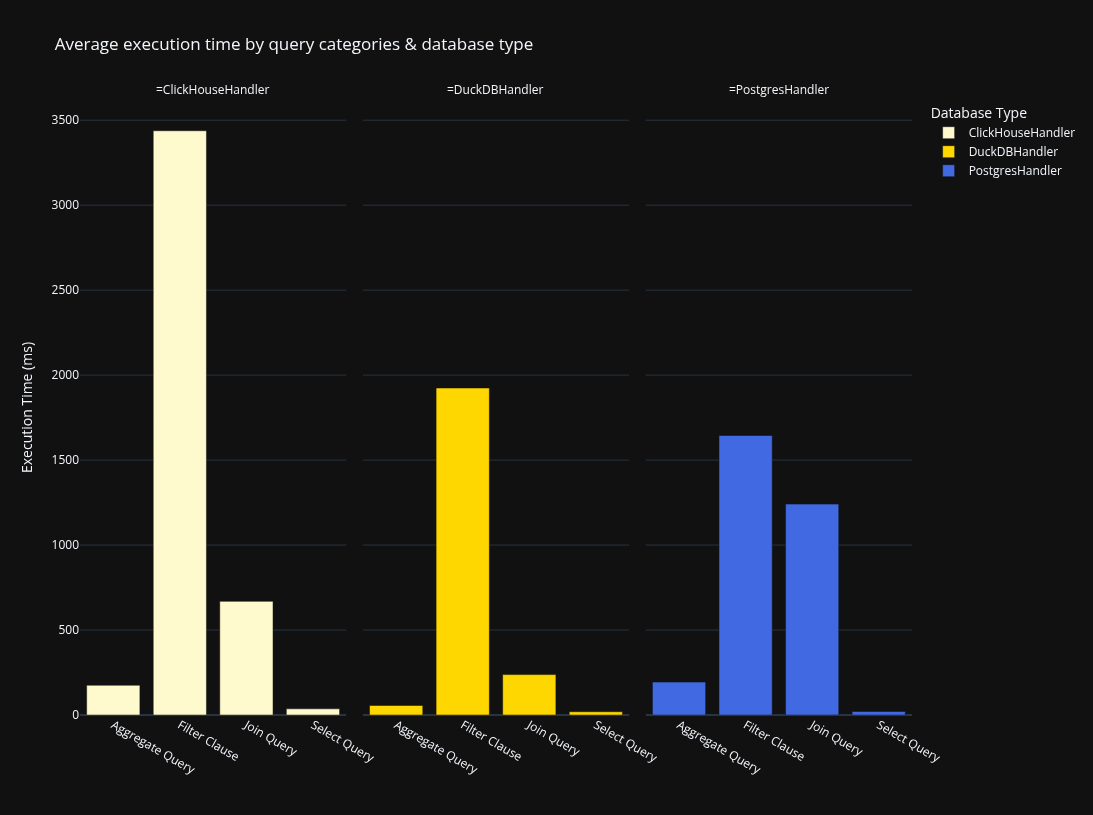

In [75]:
unqiue_ranked = ranked_queries.df().groupby(["query_category", "database_type"])["execution_time_ms"].mean().reset_index()

fig = px.bar(
    unqiue_ranked,
    x='query_category',
    y='execution_time_ms',
    color='database_type',  
    facet_col='database_type',
    color_discrete_map=color_map,
    #text='query_category',
    template=template,
    title='Average execution time by query categories & database type',
    labels={'execution_time_ms': 'Execution Time (ms)', 'database_type': '', 'query_category': ''},
    height=800,
    width=1200
)

# Customize the layout
fig.update_layout(

    #xaxis_title="Database Type",
    yaxis_title="Execution Time (ms)",
    legend_title="Database Type",
)

fig.show()

### Analyse network usage per database



In [81]:
results_df.describe()

,execution_time_ms,cpu_usage_percent,memory_usage_mb,memory_usage_percent,disk_read_mb,disk_write_mb,network_in_mb,network_out_mb,result_rows,result_size_mb,cpu_limit,memory_limit
count,1127.000000,1127.000000,1127.000000,1127.000000,1127.0,1127.0,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000
mean,2943.930745,2.152287,1727.222590,23.470591,0.0,0.0,0.124941,28.328250,57325.683230,64.027185,8.857143,21.826087
std,11714.057522,2.713487,1111.941561,30.287497,0.0,0.0,0.433446,78.882311,65869.323847,146.703703,5.223937,21.758523
min,2.125978,0.000799,100.183594,0.152928,0.0,0.0,0.000000,0.000000,1.000000,0.000134,2.000000,2.000000
25%,20.758271,0.006496,100.707031,2.597356,0.0,0.0,0.000000,0.000000,1.000000,0.000156,4.000000,4.000000
50%,153.299809,0.911000,2020.351562,9.876406,0.0,0.0,0.002903,0.082720,3097.000000,3.920194,8.000000,16.000000
75%,1202.790856,2.468528,2109.033203,39.307523,0.0,0.0,0.018562,3.478911,127197.000000,11.281813,14.000000,32.000000
max,62790.190458,17.793159,3300.445312,99.999428,0.0,0.0,2.102222,264.643103,154682.000000,433.563977,18.000000,64.000000


In [82]:
results_df.loc[results_df['database_type'] == 'DuckDBHandler', 'network_in_mb'] //= 100
results_df.loc[results_df['database_type'] == 'DuckDBHandler', 'network_out_mb'] //= 100

In [84]:
network = duckdb.sql("""
    SELECT 
        database_type,
        ROUND(avg(network_in_mb),4) as avg_network_in_mb, 
        ROUND(avg(network_out_mb),4) as avg_network_out_mb,
        ROUND(max(network_out_mb),4) as max_network_out_mb,
    FROM top_df
    GROUP by 1
    ORDER BY avg_network_out_mb
    """
    )
network.df()

,database_type,avg_network_in_mb,avg_network_out_mb,max_network_out_mb
0,DuckDBHandler,0.0000,0.0000,0.0000
1,ClickHouseHandler,0.0134,37.2449,251.7494
2,MySQLHandler,0.1541,37.9430,255.6997
3,PostgresHandler,0.3162,39.6073,264.6326


In [85]:
top_df.columns

Index(['query', 'original_query', 'database_type', 'execution_time_ms',
       'cpu_usage_percent', 'memory_usage_mb', 'memory_usage_percent',
       'disk_read_mb', 'disk_write_mb', 'network_in_mb', 'network_out_mb',
       'result_rows', 'result_size_mb', 'failed', 'cpu_limit', 'memory_limit'],
      dtype='object')

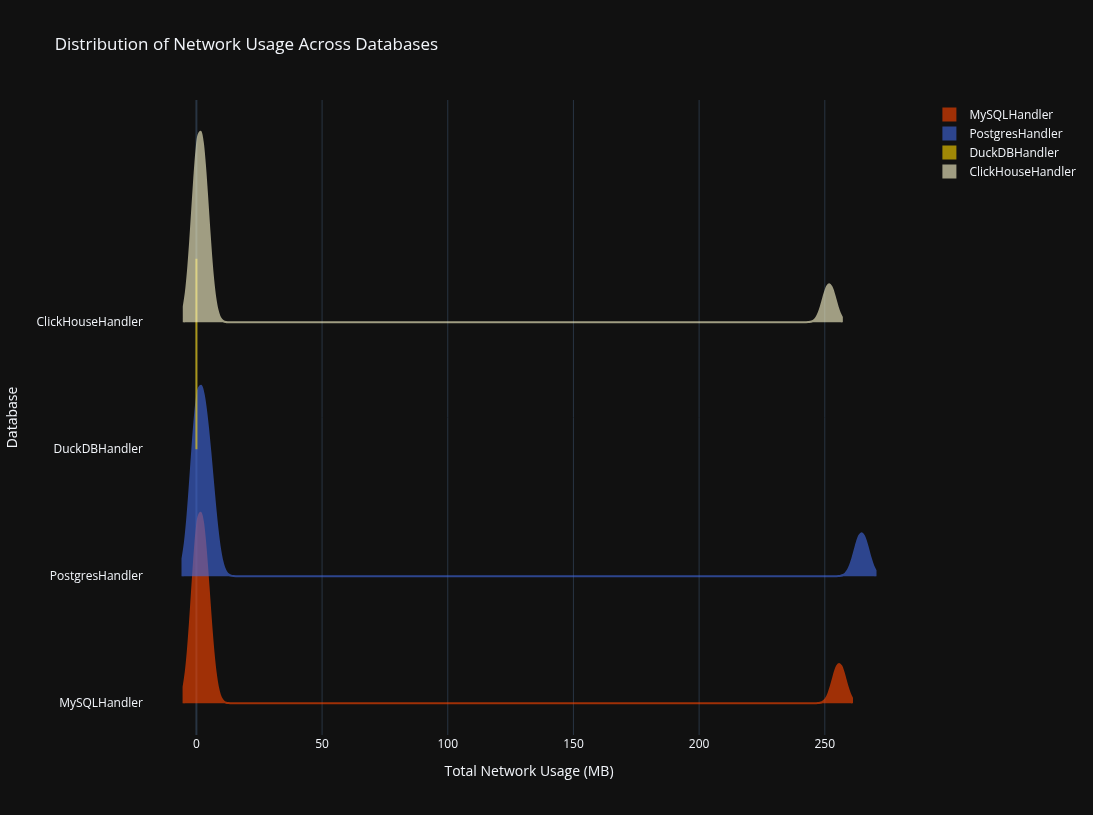

In [86]:
fig = go.Figure()
databases = top_df['database_type'].unique()

for db in databases:
    # Filter the DataFrame for the current database
    db_data = top_df[top_df['database_type'] == db]
    
    specific_color = color_map.get(db) 
    
    fig.add_trace(
        go.Violin(
            x=db_data['network_out_mb'],
            line_color=specific_color, # Assign the specific color here
            name=db,
            # For violin plots, you often want to color the fill as well for better visuals
            fillcolor=specific_color,
            opacity=0.6,
            line_width=2
        )
    )

# The rest of your layout code is great
fig.update_traces(orientation='h', side='positive', width=3, points=False)
fig.update_layout(
    xaxis_title="Total Network Usage (MB)",
    yaxis_title="Database", # Added a y-axis title for clarity
    title="Distribution of Network Usage Across Databases",
    showlegend=True,
    template=template,
    height=800,
    width=1200,
)
fig.show()



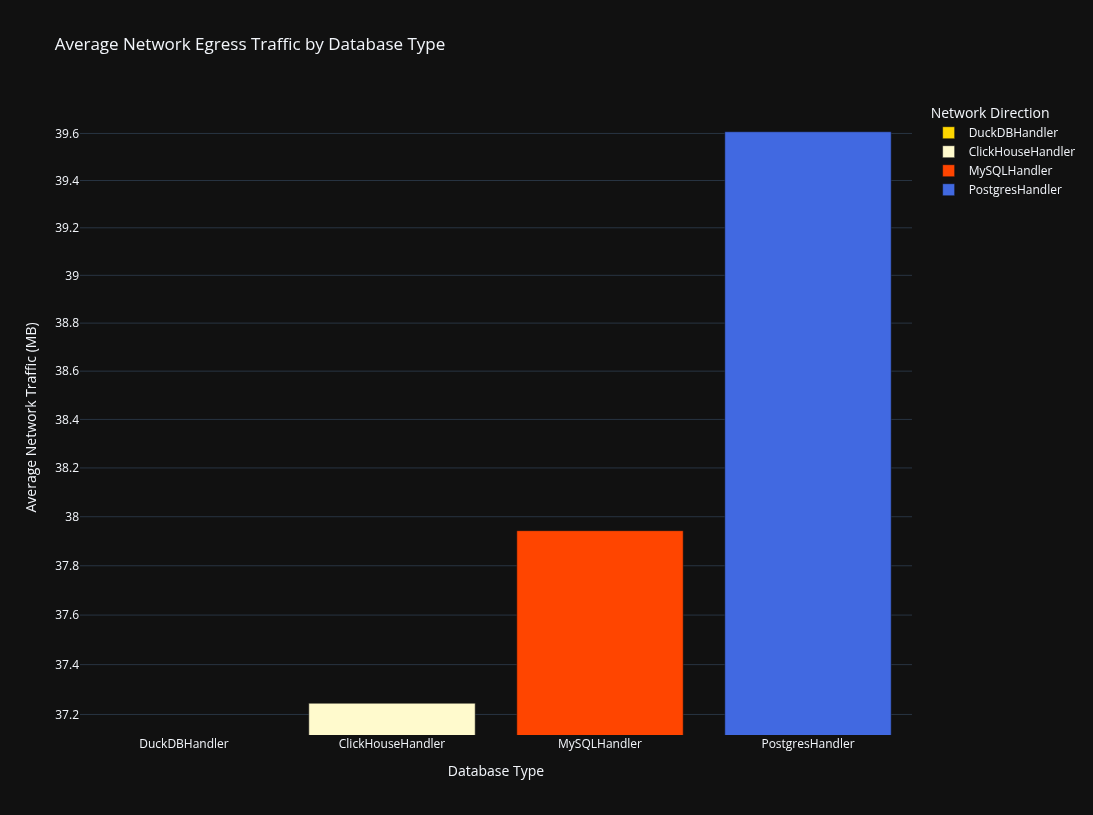

In [87]:
network_bar = px.bar(
    network,
    x='database_type',
    y='avg_network_out_mb',
    color='database_type',
    color_discrete_map=color_map,
    template=template,
    title='Average Network Egress Traffic by Database Type',
    height=800,
    width=1200
)

# Customize the layout
network_bar.update_layout(
    xaxis_title="Database Type",
    yaxis_title="Average Network Traffic (MB)",
    legend_title="Network Direction",
    yaxis_type='log'
)

network_bar.show()

## 3D plot

compare execution time by cpu core and ram usage

In [88]:
round(results_df.describe(),2)

,execution_time_ms,cpu_usage_percent,memory_usage_mb,memory_usage_percent,disk_read_mb,disk_write_mb,network_in_mb,network_out_mb,result_rows,result_size_mb,cpu_limit,memory_limit
count,1127.00,1127.00,1127.00,1127.00,1127.0,1127.0,1127.00,1127.00,1127.00,1127.00,1127.00,1127.00
mean,2943.93,2.15,1727.22,23.47,0.0,0.0,0.12,28.33,57325.68,64.03,8.86,21.83
std,11714.06,2.71,1111.94,30.29,0.0,0.0,0.43,78.88,65869.32,146.70,5.22,21.76
min,2.13,0.00,100.18,0.15,0.0,0.0,0.00,0.00,1.00,0.00,2.00,2.00
25%,20.76,0.01,100.71,2.60,0.0,0.0,0.00,0.00,1.00,0.00,4.00,4.00
50%,153.30,0.91,2020.35,9.88,0.0,0.0,0.00,0.08,3097.00,3.92,8.00,16.00
75%,1202.79,2.47,2109.03,39.31,0.0,0.0,0.02,3.48,127197.00,11.28,14.00,32.00
max,62790.19,17.79,3300.45,100.00,0.0,0.0,2.10,264.64,154682.00,433.56,18.00,64.00


In [89]:
#TODO: graph per database 
#TODO VERIFY RAM SCALE

results_df['database_type'].unique()

array(['MySQLHandler', 'PostgresHandler', 'DuckDBHandler',
       'ClickHouseHandler'], dtype=object)

In [92]:
results_df.columns

Index(['query', 'original_query', 'database_type', 'execution_time_ms',
       'cpu_usage_percent', 'memory_usage_mb', 'memory_usage_percent',
       'disk_read_mb', 'disk_write_mb', 'network_in_mb', 'network_out_mb',
       'result_rows', 'result_size_mb', 'failed', 'cpu_limit', 'memory_limit'],
      dtype='object')

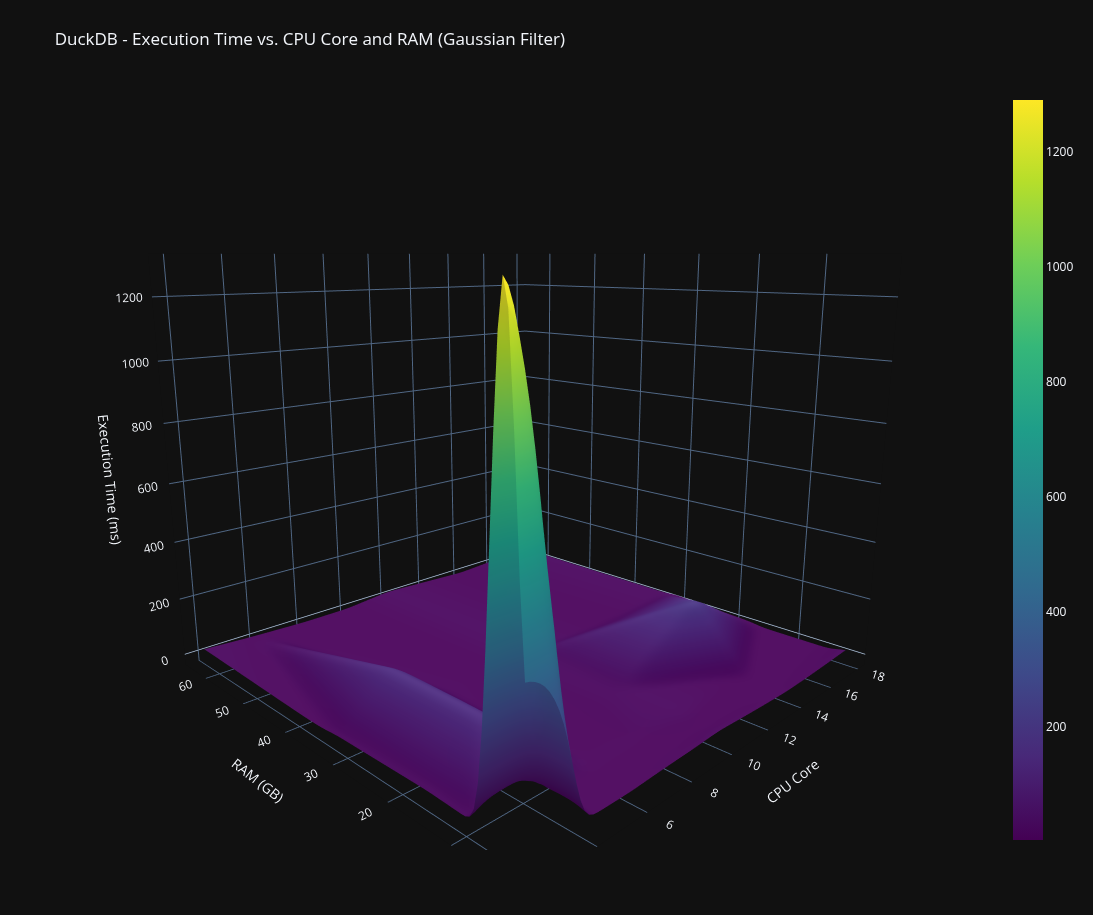

In [98]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# for duckdb
ddb = results_df[results_df['database_type'] == 'DuckDBHandler']

# Extract data
x = ddb['cpu_limit'].values
y = ddb['memory_limit'].values
z = ddb['execution_time_ms'].values

# Create grid for interpolation
num_points = 100
xi = np.linspace(x.min(), x.max(), num_points)
yi = np.linspace(y.min(), y.max(), num_points)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Interpolate data to a grid using a simple linear method
zi_raw = griddata((x, y), z, (xi_grid, yi_grid), method='linear')

# Apply a Gaussian filter to smooth the interpolated data
# Adjust the 'sigma' value to control the amount of smoothing.
# A larger sigma value results in more smoothing.
zi_smoothed = gaussian_filter(zi_raw, sigma=1.5)

# Create the 3D plot using Plotly
fig = go.Figure(
    data=[go.Surface(z=zi_smoothed, x=xi_grid, y=yi_grid, colorscale='Viridis')],
    layout=go.Layout(template=template),
)

# Customize the plot with adjusted camera position to bring origin closer to viewpoint
fig.update_layout(
    title='DuckDB - Execution Time vs. CPU Core and RAM (Gaussian Filter)',
    scene=dict(
        xaxis=dict(
            title='CPU Core',
            # Set range to start from 0 or slightly below minimum
            range=[max(0, x.min() - 1), x.max()],
            # Reverse axis direction to bring origin closer to camera
            autorange='reversed'
        ),
        yaxis=dict(
            title='RAM (GB)',
            # Set range to start from 0 or slightly below minimum
            #range=[max(0, y.min() - 100), y.max()],
            autorange='reversed'
        ),
        zaxis=dict(
            title='Execution Time (ms)',
            # Set range to start from 0 or slightly below minimum
            #range=[0, z.max() * 1.1]
        ),
        aspectratio=dict(x=1.2, y=1.2, z=1),
        # Adjust camera position to look at origin from a better angle
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=.5),
            center=dict(x=0, y=0, z=0),
            up=dict(x=0, y=0, z=1)
        )
    ),
    height=900,
    width=1200,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig.show()

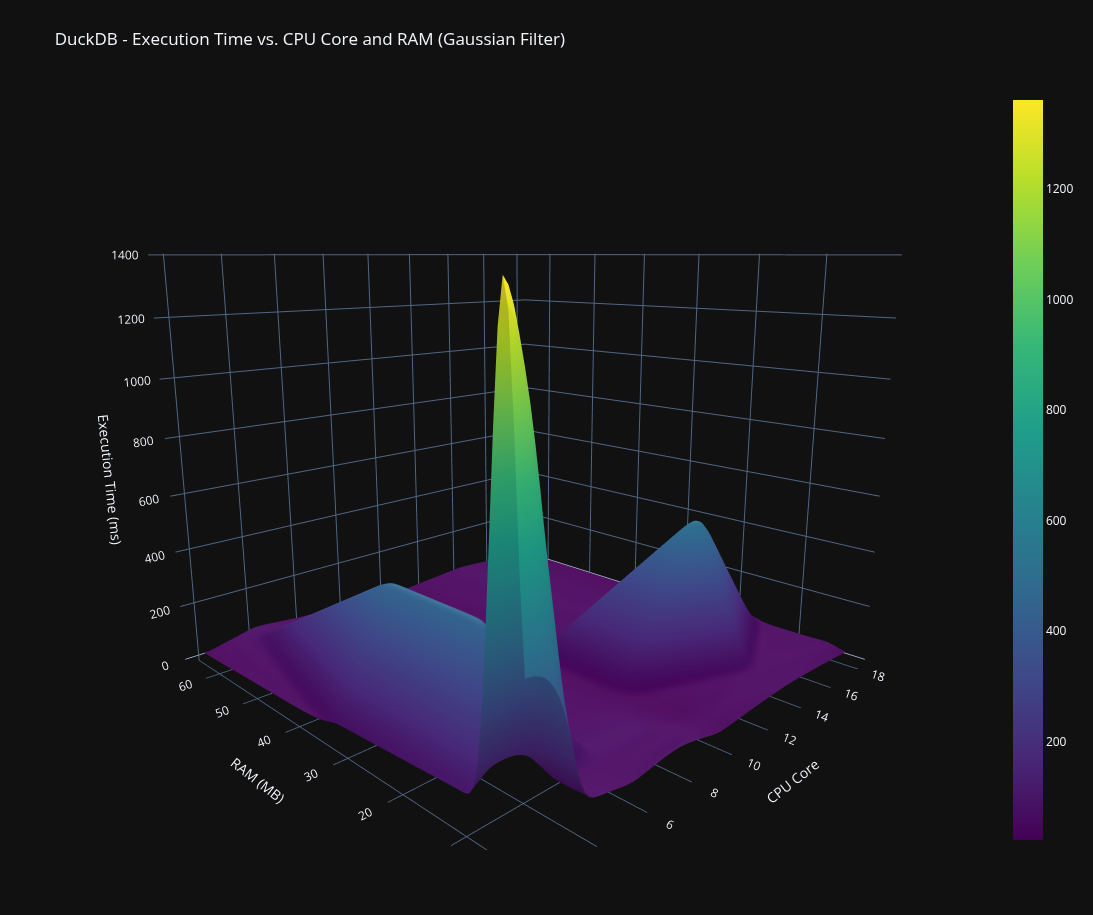

In [99]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# for duckdb
ddb = results_df[results_df['database_type'] == 'PostgresHandler']

# Extract data
x = ddb['cpu_limit'].values
y = ddb['memory_limit'].values
z = ddb['execution_time_ms'].values

# Create grid for interpolation
num_points = 100
xi = np.linspace(x.min(), x.max(), num_points)
yi = np.linspace(y.min(), y.max(), num_points)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Interpolate data to a grid using a simple linear method
zi_raw = griddata((x, y), z, (xi_grid, yi_grid), method='linear')

# Apply a Gaussian filter to smooth the interpolated data
# Adjust the 'sigma' value to control the amount of smoothing.
# A larger sigma value results in more smoothing.
zi_smoothed = gaussian_filter(zi_raw, sigma=1.5)

# Create the 3D plot using Plotly
fig = go.Figure(
    data=[go.Surface(z=zi_smoothed, x=xi_grid, y=yi_grid, colorscale='Viridis')],
    layout=go.Layout(template=template),
)

# Customize the plot with adjusted camera position to bring origin closer to viewpoint
fig.update_layout(
    title='DuckDB - Execution Time vs. CPU Core and RAM (Gaussian Filter)',
    scene=dict(
        xaxis=dict(
            title='CPU Core',
            # Set range to start from 0 or slightly below minimum
            range=[max(0, x.min() - 1), x.max()],
            # Reverse axis direction to bring origin closer to camera
            autorange='reversed'
        ),
        yaxis=dict(
            title='RAM (MB)',
            # Set range to start from 0 or slightly below minimum
            #range=[max(0, y.min() - 100), y.max()],
            autorange='reversed'
        ),
        zaxis=dict(
            title='Execution Time (ms)',
            # Set range to start from 0 or slightly below minimum
            #range=[0, z.max() * 1.1]
        ),
        aspectratio=dict(x=1.2, y=1.2, z=1),
        # Adjust camera position to look at origin from a better angle
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=.5),
            center=dict(x=0, y=0, z=0),
            up=dict(x=0, y=0, z=1)
        )
    ),
    height=900,
    width=1200,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig.show()

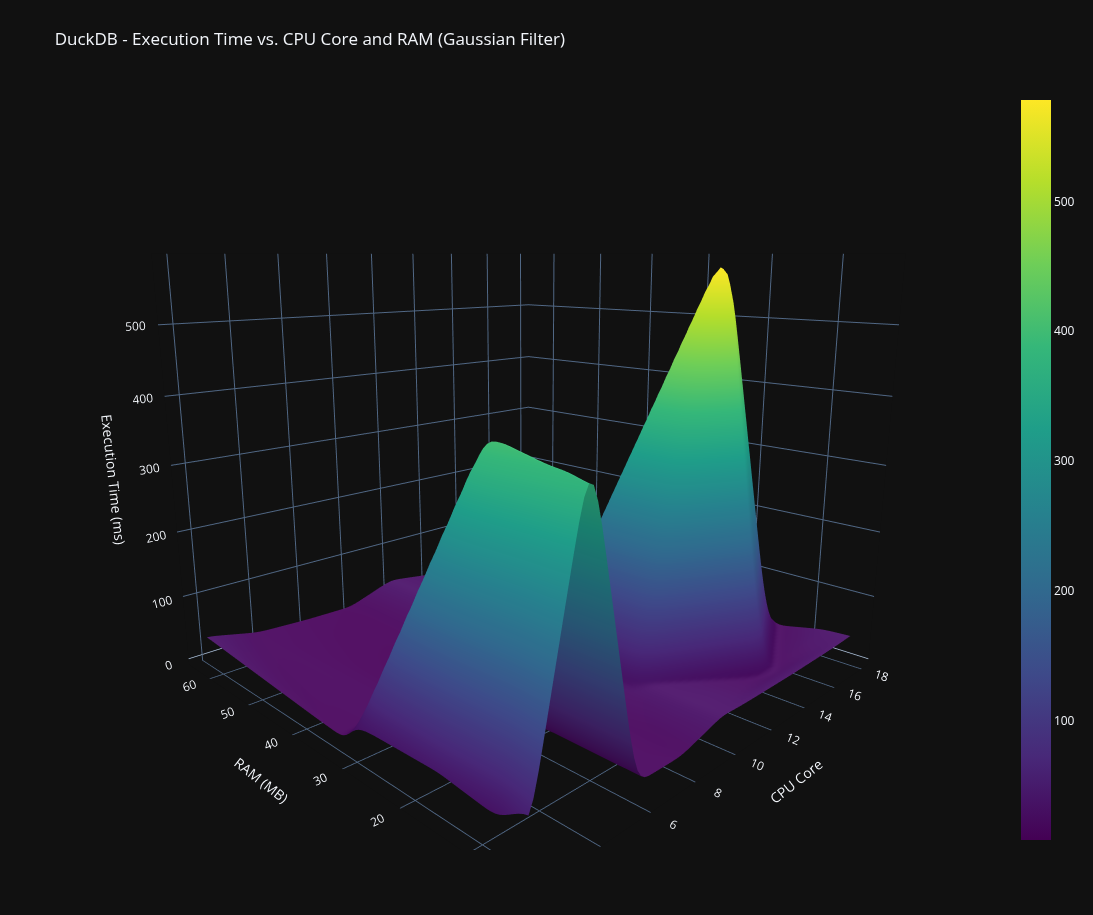

In [102]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# for duckdb
ddb = results_df[results_df['database_type'] == 'ClickHouseHandler']

# Extract data
x = ddb['cpu_limit'].values
y = ddb['memory_limit'].values
z = ddb['execution_time_ms'].values

# Create grid for interpolation
num_points = 100
xi = np.linspace(x.min(), x.max(), num_points)
yi = np.linspace(y.min(), y.max(), num_points)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Interpolate data to a grid using a simple linear method
zi_raw = griddata((x, y), z, (xi_grid, yi_grid), method='linear')

# Apply a Gaussian filter to smooth the interpolated data
# Adjust the 'sigma' value to control the amount of smoothing.
# A larger sigma value results in more smoothing.
zi_smoothed = gaussian_filter(zi_raw, sigma=1.5)

# Create the 3D plot using Plotly
fig = go.Figure(
    data=[go.Surface(z=zi_smoothed, x=xi_grid, y=yi_grid, colorscale='Viridis')],
    layout=go.Layout(template=template),
)

# Customize the plot with adjusted camera position to bring origin closer to viewpoint
fig.update_layout(
    title='DuckDB - Execution Time vs. CPU Core and RAM (Gaussian Filter)',
    scene=dict(
        xaxis=dict(
            title='CPU Core',
            # Set range to start from 0 or slightly below minimum
            range=[max(0, x.min() - 1), x.max()],
            # Reverse axis direction to bring origin closer to camera
            autorange='reversed'
        ),
        yaxis=dict(
            title='RAM (MB)',
            # Set range to start from 0 or slightly below minimum
            #range=[max(0, y.min() - 100), y.max()],
            autorange='reversed'
        ),
        zaxis=dict(
            title='Execution Time (ms)',
            # Set range to start from 0 or slightly below minimum
            #range=[0, z.max() * 1.1]
        ),
        aspectratio=dict(x=1.2, y=1.2, z=1),
        # Adjust camera position to look at origin from a better angle
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=.5),
            center=dict(x=0, y=0, z=0),
            up=dict(x=0, y=0, z=1)
        )
    ),
    height=900,
    width=1200,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig.show()

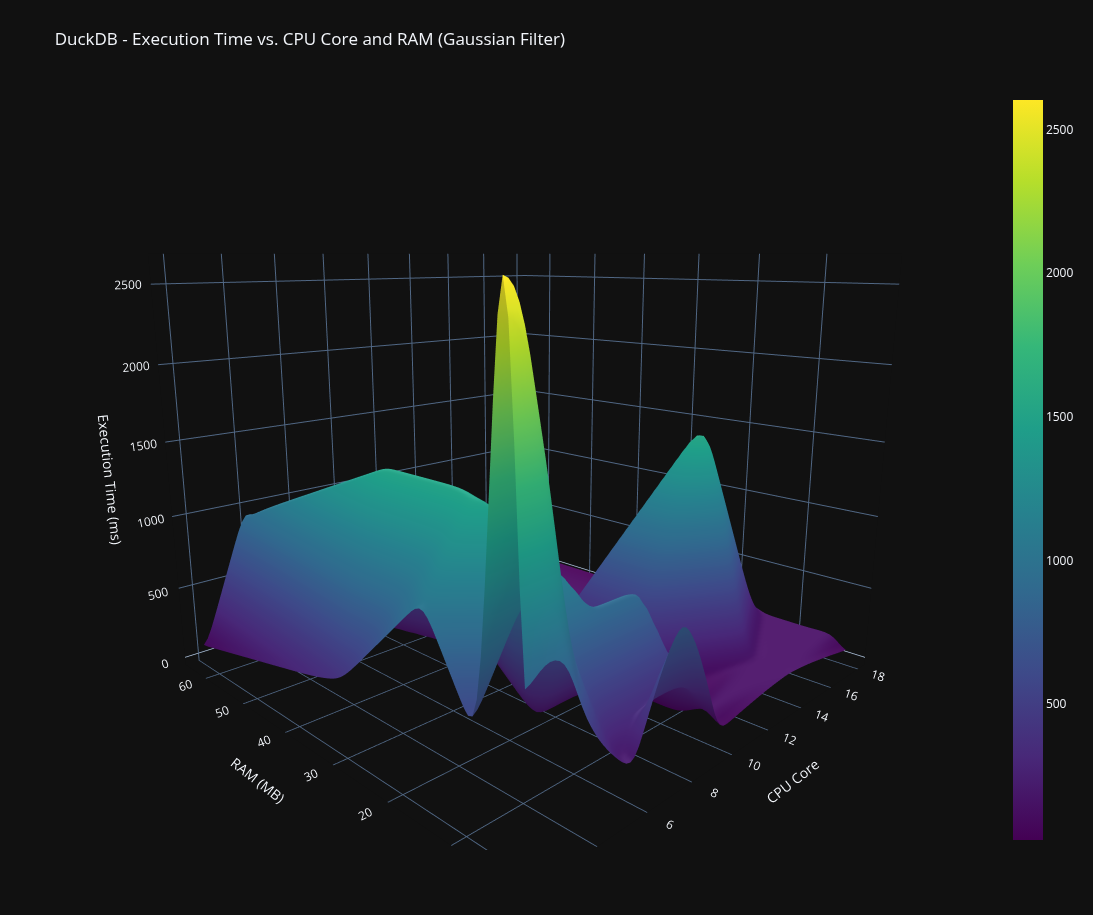

In [103]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# for duckdb
ddb = results_df[results_df['database_type'] == 'MySQLHandler']

# Extract data
x = ddb['cpu_limit'].values
y = ddb['memory_limit'].values
z = ddb['execution_time_ms'].values

# Create grid for interpolation
num_points = 100
xi = np.linspace(x.min(), x.max(), num_points)
yi = np.linspace(y.min(), y.max(), num_points)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Interpolate data to a grid using a simple linear method
zi_raw = griddata((x, y), z, (xi_grid, yi_grid), method='linear')

# Apply a Gaussian filter to smooth the interpolated data
# Adjust the 'sigma' value to control the amount of smoothing.
# A larger sigma value results in more smoothing.
zi_smoothed = gaussian_filter(zi_raw, sigma=1.5)

# Create the 3D plot using Plotly
fig = go.Figure(
    data=[go.Surface(z=zi_smoothed, x=xi_grid, y=yi_grid, colorscale='Viridis')],
    layout=go.Layout(template=template),
)

# Customize the plot with adjusted camera position to bring origin closer to viewpoint
fig.update_layout(
    title='DuckDB - Execution Time vs. CPU Core and RAM (Gaussian Filter)',
    scene=dict(
        xaxis=dict(
            title='CPU Core',
            # Set range to start from 0 or slightly below minimum
            range=[max(0, x.min() - 1), x.max()],
            # Reverse axis direction to bring origin closer to camera
            autorange='reversed'
        ),
        yaxis=dict(
            title='RAM (MB)',
            # Set range to start from 0 or slightly below minimum
            #range=[max(0, y.min() - 100), y.max()],
            autorange='reversed'
        ),
        zaxis=dict(
            title='Execution Time (ms)',
            # Set range to start from 0 or slightly below minimum
            #range=[0, z.max() * 1.1]
        ),
        aspectratio=dict(x=1.2, y=1.2, z=1),
        # Adjust camera position to look at origin from a better angle
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=.5),
            center=dict(x=0, y=0, z=0),
            up=dict(x=0, y=0, z=1)
        )
    ),
    height=900,
    width=1200,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig.show()

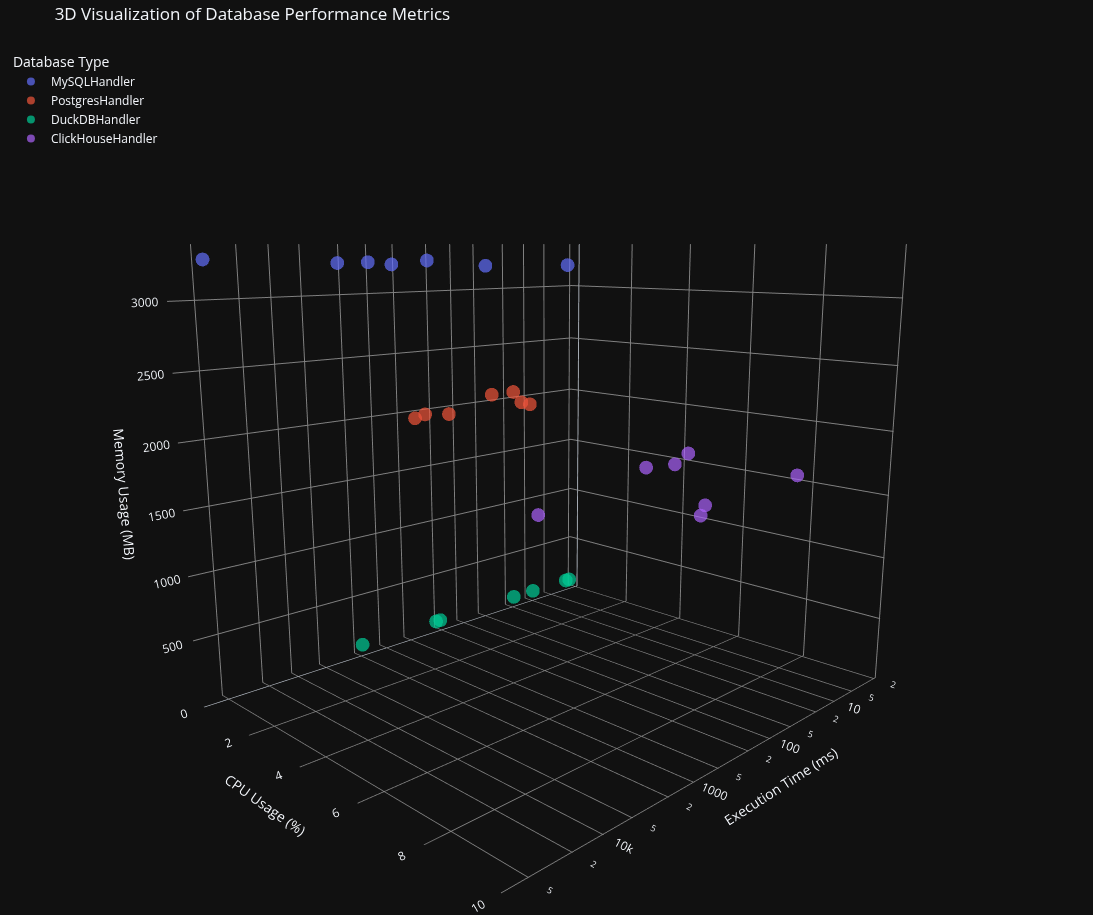

In [104]:
# 3D Plot with increased size
# Create a 3D scatter plot to visualize the relationship between execution time, CPU usage, and memory usage
fig_3d = px.scatter_3d(
    top_df,
    x='execution_time_ms',
    y='cpu_usage_percent',
    z='memory_usage_mb',
    color='database_type',
    #size='database_type',  # result_rows# Size points by the number of result rows
    opacity=0.7,
    template=template,
    title='3D Visualization of Database Performance Metrics',
    labels={
        'execution_time_ms': 'Execution Time (ms)',
        'cpu_usage_percent': 'CPU Usage (%)',
        'memory_usage_mb': 'Memory Usage (MB)',
        'database_type': 'Database Type',
        'result_rows': 'Result Rows'
    },
    # Increase the size of the 3D plot
    height=900,  
    width=1200   
)

# Update the layout to make the 3D plot more readable
fig_3d.update_layout(
    scene=dict(
        xaxis=dict(
            title_font=dict(size=14),
            type='log',  # Log scale for execution time
            backgroundcolor='rgba(0,0,0,0)',
            gridcolor='gray',
            showbackground=True
        ),
        yaxis=dict(
            title_font=dict(size=14),
            backgroundcolor='rgba(0,0,0,0)',
            gridcolor='gray',
            showbackground=True
        ),
        zaxis=dict(
            title_font=dict(size=14),
            backgroundcolor='rgba(0,0,0,0)',
            gridcolor='gray',
            showbackground=True
        ),
        aspectratio=dict(x=1.2, y=1, z=1),  # Adjust aspect ratio for better visualization
        camera=dict(
            eye=dict(x=1.6, y=1.6, z=.5),  # Increased distance for better perspective
            center=dict(x=0, y=0, z=0),     # Look at the origin
            up=dict(x=0, y=0, z=1)          # Keep z-axis pointing up
        )
    ),
    margin=dict(l=0, r=0, b=0, t=40),  # Reduce margins to maximize plot area
    legend=dict(
        font=dict(size=12),
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig_3d.show()